# Soft Prompting and Soft Prefix Tuning

## CS 182: Deep Neural Networks - UC Berkeley

This notebook demonstrates **soft prompting** and **soft prefix tuning**, two parameter-efficient fine-tuning (PEFT) techniques that allow us to adapt large language models without modifying their weights.

### The Problem

When we want to optimize a prompt for a language model, we face a fundamental challenge:
- **Gradients cannot flow back through discrete token selection**
- The embedding layer maps discrete tokens → continuous embeddings, but this mapping is non-differentiable

### The Solution: Soft Prompts

Instead of using discrete tokens, we learn **continuous embeddings** directly:
1. **Soft Prompting**: Learn special token embeddings that are prepended to inputs
2. **Soft Prefix Tuning**: Learn key-value pairs at each transformer layer

### Why This Matters

| Method | Parameters (8B model, 100-token prompt) |
|--------|----------------------------------------|
| Full Fine-tuning | ~8 billion |
| Soft Prompting | ~400K (embedding_dim × prompt_length) |
| Soft Prefix | ~26M (includes K-V across layers) |

This is a **20,000x reduction** in learnable parameters!


In [2]:
# Install dependencies (uncomment if running in Colab)
# !pip install torch transformers matplotlib numpy pandas -q


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
import pandas as pd

# Set device and seed for reproducibility
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
print(f"Using device: {device}")


Using device: cpu


## 1. Building a Simple Transformer for Demonstration

We'll create a small transformer to demonstrate the concepts. In practice, you'd use a pre-trained model like GPT-2 or LLaMA.


In [5]:
class SimpleTransformer(nn.Module):
    """A minimal transformer for classification tasks."""
    
    def __init__(self, vocab_size=1000, embed_dim=128, num_heads=4, 
                 num_layers=4, num_classes=2, max_seq_len=64):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_layers = num_layers
        
        # Token and position embeddings
        self.token_embed = nn.Embedding(vocab_size, embed_dim)
        self.pos_embed = nn.Embedding(max_seq_len, embed_dim)
        
        # Transformer layers
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=256,
            dropout=0.1, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers)
        
        # Classification head
        self.classifier = nn.Linear(embed_dim, num_classes)
        
    def forward(self, x, prefix_embeds=None):
        """Forward pass with optional prefix embeddings for soft prompting."""
        batch_size, seq_len = x.shape
        
        # Get token embeddings
        tok_emb = self.token_embed(x)
        
        # Handle soft prompt prefix
        if prefix_embeds is not None:
            prefix_len = prefix_embeds.shape[1]
            # Expand prefix for batch
            prefix = prefix_embeds.expand(batch_size, -1, -1)
            tok_emb = torch.cat([prefix, tok_emb], dim=1)
            seq_len = seq_len + prefix_len
        
        # Add positional embeddings
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0)
        pos_emb = self.pos_embed(positions)
        embeddings = tok_emb + pos_emb
        
        # Transform
        hidden = self.transformer(embeddings)
        
        # Use mean pooling for classification
        pooled = hidden.mean(dim=1)
        return self.classifier(pooled)

# Initialize the base model
base_model = SimpleTransformer().to(device)
print(f"Base model parameters: {sum(p.numel() for p in base_model.parameters()):,}")


Base model parameters: 666,370


## 2. Creating a Toy Dataset

We'll create a simple sentiment classification task where the model must learn to classify sequences based on the presence of certain "positive" or "negative" tokens.


In [6]:
class SentimentDataset(Dataset):
    """Synthetic dataset where class depends on token frequency patterns."""
    
    def __init__(self, num_samples=1000, seq_len=32, vocab_size=1000):
        self.data, self.labels = [], []
        pos_tokens, neg_tokens = list(range(1, 101)), list(range(101, 201))
        neutral_tokens = list(range(201, vocab_size))
        
        for _ in range(num_samples):
            label = np.random.randint(0, 2)
            seq = []
            for _ in range(seq_len):
                if np.random.random() < 0.3:
                    seq.append(np.random.choice(pos_tokens if label == 1 else neg_tokens))
                else:
                    seq.append(np.random.choice(neutral_tokens))
            self.data.append(seq)
            self.labels.append(label)
    
    def __len__(self): return len(self.data)
    def __getitem__(self, idx): return torch.tensor(self.data[idx]), torch.tensor(self.labels[idx])

train_dataset = SentimentDataset(num_samples=2000)
val_dataset = SentimentDataset(num_samples=500)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
print(f"Training samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")


Training samples: 2000, Validation samples: 500


## 3. Soft Prompting Implementation

The key insight: instead of discrete tokens, we create **learnable embedding vectors** that are prepended to the input. These "soft" tokens can be optimized via gradient descent.

```
┌──────────────────────────────────────────────────┐
│  [SOFT_1][SOFT_2]...[SOFT_N] + [input tokens]    │
│      ↑                                           │
│  Learnable parameters (gradients flow here!)    │
└──────────────────────────────────────────────────┘
```


In [7]:
class SoftPrompt(nn.Module):
    """Learnable soft prompt embeddings."""
    
    def __init__(self, prompt_length, embed_dim, init_from_vocab=None):
        super().__init__()
        self.prompt_length = prompt_length
        if init_from_vocab is not None:
            self.soft_embeds = nn.Parameter(init_from_vocab.clone())
        else:
            self.soft_embeds = nn.Parameter(torch.randn(1, prompt_length, embed_dim) * 0.02)
    
    def forward(self):
        return self.soft_embeds

# Create soft prompt with 10 learnable tokens
PROMPT_LENGTH = 10
soft_prompt = SoftPrompt(PROMPT_LENGTH, base_model.embed_dim).to(device)

soft_params = sum(p.numel() for p in soft_prompt.parameters())
base_params = sum(p.numel() for p in base_model.parameters())
print(f"Soft prompt parameters: {soft_params:,}")
print(f"Reduction ratio: {base_params / soft_params:.1f}x fewer parameters")


Soft prompt parameters: 1,280
Reduction ratio: 520.6x fewer parameters


## 4. Training with Soft Prompting

We freeze the base model and only train the soft prompt embeddings.


In [ ]:
def train_epoch(model, soft_prompt, dataloader, optimizer, freeze_base=True):
    """Train for one epoch."""
    model.train()
    if freeze_base:
        for param in model.parameters():
            param.requires_grad = False
    
    total_loss, correct = 0, 0
    for x, y in dataloader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        prefix = soft_prompt() if soft_prompt else None
        logits = model(x, prefix_embeds=prefix)
        loss = F.cross_entropy(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (logits.argmax(1) == y).sum().item()
    return total_loss / len(dataloader), correct / len(dataloader.dataset)

def evaluate(model, soft_prompt, dataloader):
    """Evaluate model."""
    model.eval()
    correct = 0
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            prefix = soft_prompt() if soft_prompt else None
            logits = model(x, prefix_embeds=prefix)
            correct += (logits.argmax(1) == y).sum().item()
    return correct / len(dataloader.dataset)


In [9]:
# Train soft prompt
optimizer = torch.optim.AdamW(soft_prompt.parameters(), lr=0.01)
soft_prompt_history = {'train_loss': [], 'train_acc': [], 'val_acc': []}

print("Training Soft Prompt (base model frozen)...")
for epoch in range(20):
    train_loss, train_acc = train_epoch(base_model, soft_prompt, train_loader, optimizer)
    val_acc = evaluate(base_model, soft_prompt, val_loader)
    soft_prompt_history['train_loss'].append(train_loss)
    soft_prompt_history['train_acc'].append(train_acc)
    soft_prompt_history['val_acc'].append(val_acc)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}: Loss={train_loss:.4f}, Train Acc={train_acc:.3f}, Val Acc={val_acc:.3f}")


Training Soft Prompt (base model frozen)...
Epoch 5: Loss=0.6777, Train Acc=0.595, Val Acc=0.680
Epoch 10: Loss=0.6647, Train Acc=0.679, Val Acc=0.752
Epoch 15: Loss=0.6425, Train Acc=0.742, Val Acc=0.790
Epoch 20: Loss=0.6150, Train Acc=0.751, Val Acc=0.756


## 5. Soft Prefix Tuning

Soft prefix tuning extends the idea by learning **key-value pairs at each transformer layer**, not just input embeddings. This provides more control over how the model processes information.

As described in lecture: *"The past queries have no influence except how they influence the keys and values. The state is the keys and the values."*


In [10]:
class SoftPrefix(nn.Module):
    """Learnable prefix with reparameterization for better optimization."""
    
    def __init__(self, prefix_length, embed_dim, num_layers):
        super().__init__()
        self.prefix_length = prefix_length
        self.num_layers = num_layers
        # Learn prefix K-V for each layer: (num_layers, 2, prefix_length, embed_dim)
        self.prefix_kv = nn.Parameter(torch.randn(num_layers, 2, prefix_length, embed_dim) * 0.02)
        # MLP reparameterization helps optimization
        self.reparam = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2), nn.Tanh(), nn.Linear(embed_dim * 2, embed_dim)
        )
    
    def get_all_prefixes(self):
        """Get prefix embeddings (simplified: use first layer's keys)."""
        return self.reparam(self.prefix_kv[0, 0]).unsqueeze(0)

# Create soft prefix
base_model_2 = SimpleTransformer().to(device)
soft_prefix = SoftPrefix(PROMPT_LENGTH, base_model_2.embed_dim, base_model_2.num_layers).to(device)

class PrefixWrapper(nn.Module):
    def __init__(self, prefix_module):
        super().__init__()
        self.prefix = prefix_module
    def forward(self):
        return self.prefix.get_all_prefixes()

prefix_wrapper = PrefixWrapper(soft_prefix).to(device)
prefix_params = sum(p.numel() for p in soft_prefix.parameters())
print(f"Soft prefix parameters: {prefix_params:,}")


Soft prefix parameters: 76,160


In [ ]:
# Train soft prefix
optimizer = torch.optim.AdamW(soft_prefix.parameters(), lr=0.005)
prefix_history = {'train_loss': [], 'train_acc': [], 'val_acc': []}

print("Training Soft Prefix (base model frozen)...")
for epoch in range(20):
    train_loss, train_acc = train_epoch(base_model_2, prefix_wrapper, train_loader, optimizer)
    val_acc = evaluate(base_model_2, prefix_wrapper, val_loader)
    prefix_history['train_loss'].append(train_loss)
    prefix_history['train_acc'].append(train_acc)
    prefix_history['val_acc'].append(val_acc)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}: Loss={train_loss:.4f}, Train Acc={train_acc:.3f}, Val Acc={val_acc:.3f}")


Training Soft Prefix (base model frozen)...
Epoch 5: Loss=0.6000, Train Acc=0.719, Val Acc=0.722
Epoch 10: Loss=0.5473, Train Acc=0.776, Val Acc=0.806
Epoch 15: Loss=0.5141, Train Acc=0.806, Val Acc=0.838
Epoch 20: Loss=0.5002, Train Acc=0.816, Val Acc=0.870


## 6. Comparison: Full Fine-tuning vs Soft Prompting


In [12]:
# Full fine-tuning baseline
base_model_full = SimpleTransformer().to(device)
optimizer = torch.optim.AdamW(base_model_full.parameters(), lr=0.001)
full_history = {'train_loss': [], 'train_acc': [], 'val_acc': []}

print("Training Full Model (all parameters)...")
for epoch in range(20):
    base_model_full.train()
    for param in base_model_full.parameters():
        param.requires_grad = True
    train_loss, train_acc = train_epoch(base_model_full, None, train_loader, optimizer, freeze_base=False)
    val_acc = evaluate(base_model_full, None, val_loader)
    full_history['train_loss'].append(train_loss)
    full_history['train_acc'].append(train_acc)
    full_history['val_acc'].append(val_acc)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}: Loss={train_loss:.4f}, Train Acc={train_acc:.3f}, Val Acc={val_acc:.3f}")


Training Full Model (all parameters)...
Epoch 5: Loss=0.0005, Train Acc=1.000, Val Acc=0.988
Epoch 10: Loss=0.0001, Train Acc=1.000, Val Acc=0.990
Epoch 15: Loss=0.0001, Train Acc=1.000, Val Acc=0.990
Epoch 20: Loss=0.0001, Train Acc=1.000, Val Acc=0.990


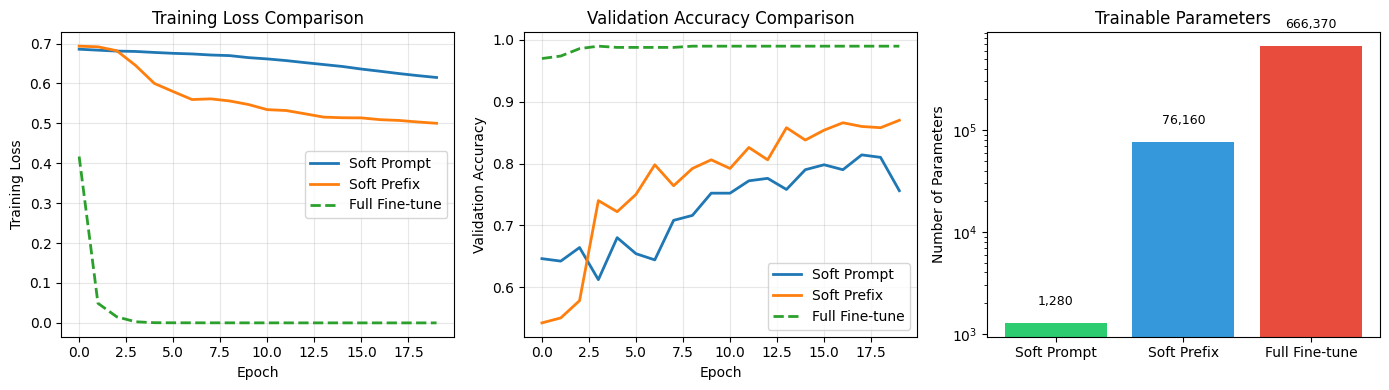

In [13]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Training loss
axes[0].plot(soft_prompt_history['train_loss'], label='Soft Prompt', linewidth=2)
axes[0].plot(prefix_history['train_loss'], label='Soft Prefix', linewidth=2)
axes[0].plot(full_history['train_loss'], label='Full Fine-tune', linewidth=2, linestyle='--')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Training Loss')
axes[0].set_title('Training Loss Comparison'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Validation accuracy
axes[1].plot(soft_prompt_history['val_acc'], label='Soft Prompt', linewidth=2)
axes[1].plot(prefix_history['val_acc'], label='Soft Prefix', linewidth=2)
axes[1].plot(full_history['val_acc'], label='Full Fine-tune', linewidth=2, linestyle='--')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Validation Accuracy Comparison'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Parameter comparison
methods = ['Soft Prompt', 'Soft Prefix', 'Full Fine-tune']
params = [soft_params, prefix_params, base_params]
colors = ['#2ecc71', '#3498db', '#e74c3c']
axes[2].bar(methods, params, color=colors)
axes[2].set_ylabel('Number of Parameters'); axes[2].set_title('Trainable Parameters'); axes[2].set_yscale('log')
for i, v in enumerate(params):
    axes[2].text(i, v * 1.5, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


## 7. Visualizing Learned Soft Prompt Embeddings


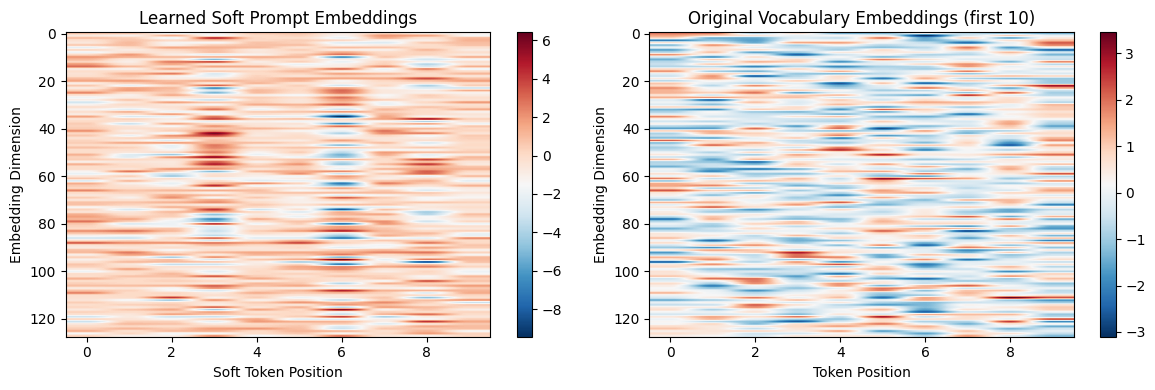

In [14]:
# Visualize learned soft prompt embeddings
soft_embeds = soft_prompt.soft_embeds.detach().cpu().squeeze(0).numpy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im = axes[0].imshow(soft_embeds.T, aspect='auto', cmap='RdBu_r')
axes[0].set_xlabel('Soft Token Position'); axes[0].set_ylabel('Embedding Dimension')
axes[0].set_title('Learned Soft Prompt Embeddings'); plt.colorbar(im, ax=axes[0])

random_embeds = base_model.token_embed.weight[:PROMPT_LENGTH].detach().cpu().numpy()
im2 = axes[1].imshow(random_embeds.T, aspect='auto', cmap='RdBu_r')
axes[1].set_xlabel('Token Position'); axes[1].set_ylabel('Embedding Dimension')
axes[1].set_title('Original Vocabulary Embeddings (first 10)'); plt.colorbar(im2, ax=axes[1])
plt.tight_layout(); plt.show()


In [ ]:
# Summary statistics
results_df = pd.DataFrame({
    'Method': ['Soft Prompt', 'Soft Prefix', 'Full Fine-tune'],
    'Parameters': [soft_params, prefix_params, base_params],
    'Final Val Acc': [soft_prompt_history['val_acc'][-1], prefix_history['val_acc'][-1], full_history['val_acc'][-1]],
    'Best Val Acc': [max(soft_prompt_history['val_acc']), max(prefix_history['val_acc']), max(full_history['val_acc'])]
})
results_df['Param Reduction'] = results_df['Parameters'].max() / results_df['Parameters']
results_df['Param Reduction'] = results_df['Param Reduction'].apply(lambda x: f'{x:.1f}x')

print("\n" + "="*60)
print("RESULTS SUMMARY")
print("="*60)
print(results_df.to_string(index=False))



RESULTS SUMMARY
        Method  Parameters  Final Val Acc  Best Val Acc Param Reduction
   Soft Prompt        1280          0.756         0.814          520.6x
   Soft Prefix       76160          0.870         0.870            8.7x
Full Fine-tune      666370          0.990         0.990            1.0x


## Key Takeaways

### 1. The Core Insight
Discrete prompts can't be optimized with gradients because the embedding lookup is non-differentiable. **Soft prompts bypass this by directly learning continuous embeddings.**

### 2. Trade-offs

| Aspect | Soft Prompt | Soft Prefix | Full Fine-tune |
|--------|-------------|-------------|----------------|
| Parameters | Very few | Few | All |
| Expressiveness | Limited | Moderate | Full |
| Training cost | Low | Low | High |
| Model modification | None | None | All weights |

### 3. When to Use What

- **Soft Prompting**: When you have limited compute and the task is closely related to pre-training
- **Soft Prefix**: When you need more control but still want parameter efficiency  
- **Full Fine-tuning**: When you have compute budget and need maximum performance

### 4. Scaling Behavior
As noted in lecture: *"The bigger the model, the better soft prompting works."* Large pre-trained models are more "steerable" with small prompts.

### 5. Important Details from Lecture

- Soft prompts don't transfer across models (unlike natural language prompts optimized via DSPY)
- The prompt length is a hyperparameter you can sweep over
- You can optionally quantize soft prompts back to discrete tokens (won't be human-interpretable)

### References
- Lester et al., "The Power of Scale for Parameter-Efficient Prompt Tuning" (2021)
- Li & Liang, "Prefix-Tuning: Optimizing Continuous Prompts for Generation" (2021)
